<a href="https://colab.research.google.com/github/asmi2604/Jamboree_Admission_Analysis/blob/main/Jamboree_Admission_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Jamboree Education — Graduate Admissions Predictor
## A Complete Machine Learning Case Study

---

> **Author:** Asmita Rajendra
> **Date:** April 2026  
> **Tools:** Python · Pandas · Seaborn · Statsmodels · Scikit-learn

---

## 📋 Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Import Libraries & Load Data](#2-import-libraries--load-data)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Model Building — Linear Regression](#5-model-building)
6. [Assumption Testing](#6-assumption-testing)
7. [Model Evaluation](#7-model-evaluation)
8. [Ridge & Lasso Regression](#8-ridge--lasso-regression)
9. [Actionable Insights & Recommendations](#9-actionable-insights--recommendations)

---

## 1. Problem Statement

Jamboree Education helps thousands of Indian students secure admissions at top universities abroad. They have launched a feature that **estimates the probability of a student's admission into Ivy League colleges**.

### Objective
Build a **Linear Regression model** that:
- Identifies the **key factors** influencing graduate admissions
- Understands **inter-relationships** between predictor variables
- **Predicts** a student's chance of admission given their academic profile

### 📊 Dataset Overview
| Feature | Description | Range |
|---|---|---|
| `GRE Score` | Graduate Record Examination score | 0–340 |
| `TOEFL Score` | Test of English as a Foreign Language | 0–120 |
| `University Rating` | Prestige of the undergraduate university | 1–5 |
| `SOP` | Statement of Purpose strength | 1–5 |
| `LOR` | Letter of Recommendation strength | 1–5 |
| `CGPA` | Undergraduate GPA | 0–10 |
| `Research` | Research experience (binary) | 0 or 1 |
| `Chance of Admit` | 🎯 **Target variable** — probability of admission | 0–1 |

### 💡 Business Questions
1. Which academic factors most strongly predict admission chances?
2. Is CGPA or GRE score more important?
3. Does research experience significantly boost admission probability?
4. Can Jamboree reliably score applicants and offer personalized feedback?

---

## 2. Import Libraries & Load Data

In [ ]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Set a clean, professional style
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED', '#0891B2', '#DB2777']
sns.set_palette(PALETTE)

# ── Statistical / ML ────────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
# Option A — if running in Colab and you've uploaded the file:
df = pd.read_csv('Jamboree_Admission.csv')

# Option B — load directly from GitHub (replace URL with your repo raw link):
# df = pd.read_csv('https://raw.githubusercontent.com/YOUR_USERNAME/YOUR_REPO/main/Jamboree_Admission.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset loaded: 500 rows × 9 columns


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
5,6,330,115,5,4.5,3.0,9.34,1,0.90
6,7,321,109,3,3.0,4.0,8.20,1,0.75
7,8,308,101,2,3.0,4.0,7.90,0,0.68
8,9,302,102,1,2.0,1.5,8.00,0,0.50
9,10,323,108,3,3.5,3.0,8.60,0,0.45


---
## 3. Exploratory Data Analysis
### 3.1 Structure & Data Types

In [ ]:

print("  DATASET SHAPE")

print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print("  COLUMN NAMES")
print(df.columns.tolist())
print("  DATA TYPES")
print(df.dtypes)

  DATASET SHAPE
  Rows    : 500
  Columns : 9
  COLUMN NAMES
['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']
  DATA TYPES
Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object


In [ ]:
# ── Drop Serial No. (unique row ID — adds no predictive value) ───────────────
df.drop(columns=['Serial No.'], inplace=True)

# ── Clean column names (strip trailing spaces) ───────────────────────────────
df.columns = df.columns.str.strip()

# ── Rename for convenience ────────────────────────────────────────────────────
df.rename(columns={
    'GRE Score':       'GRE',
    'TOEFL Score':     'TOEFL',
    'University Rating': 'Univ_Rating',
    'LOR ':            'LOR',
    'Chance of Admit ': 'Admit_Chance',
    'Chance of Admit':  'Admit_Chance'
}, inplace=True)

# Handle possible column naming variations
df.columns = [c.strip() for c in df.columns]
df.rename(columns={'Chance of Admit': 'Admit_Chance'}, inplace=True)

print("✅ Cleaned columns:", df.columns.tolist())
df.head()

✅ Cleaned columns: ['GRE', 'TOEFL', 'Univ_Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Admit_Chance']


,GRE,TOEFL,Univ_Rating,SOP,LOR,CGPA,Research,Admit_Chance
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


### 3.2 Statistical Summary

In [ ]:
desc = df.describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(2)   # Coefficient of Variation
desc['range'] = desc['max'] - desc['min']
desc.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'cv%']).format(precision=3)

,count,mean,std,min,25%,50%,75%,max,cv%,range
GRE,500.000,316.472,11.295,290.000,308.000,317.000,325.000,340.000,3.570,50.000
TOEFL,500.000,107.192,6.082,92.000,103.000,107.000,112.000,120.000,5.670,28.000
Univ_Rating,500.000,3.114,1.144,1.000,2.000,3.000,4.000,5.000,36.720,4.000
SOP,500.000,3.374,0.991,1.000,2.500,3.500,4.000,5.000,29.370,4.000
LOR,500.000,3.484,0.925,1.000,3.000,3.500,4.000,5.000,26.560,4.000
CGPA,500.000,8.576,0.605,6.800,8.128,8.560,9.040,9.920,7.050,3.120
Research,500.000,0.560,0.497,0.000,0.000,1.000,1.000,1.000,88.730,1.000
Admit_Chance,500.000,0.722,0.141,0.340,0.630,0.720,0.820,0.970,19.560,0.630


In [ ]:
print("━" * 4)
print("  MISSING VALUES")
print("━" * 4)
missing = df.isnull().sum()
print(missing)
print(f"\n✅ Total missing values: {missing.sum()}")

print("\n━" * 4)
print("  DUPLICATE ROWS")
print("━" * 4)
dupes = df.duplicated().sum()
print(f"  Duplicate rows: {dupes}")
print("✅ No issues found" if dupes == 0 else f"⚠️  Found {dupes} duplicates — investigate!")

━━━━
  MISSING VALUES
━━━━
GRE             0
TOEFL           0
Univ_Rating     0
SOP             0
LOR             0
CGPA            0
Research        0
Admit_Chance    0
dtype: int64

✅ Total missing values: 0

━
━
━
━
  DUPLICATE ROWS
━━━━
  Duplicate rows: 0
✅ No issues found


### 3.3 Univariate Analysis — Continuous Variables

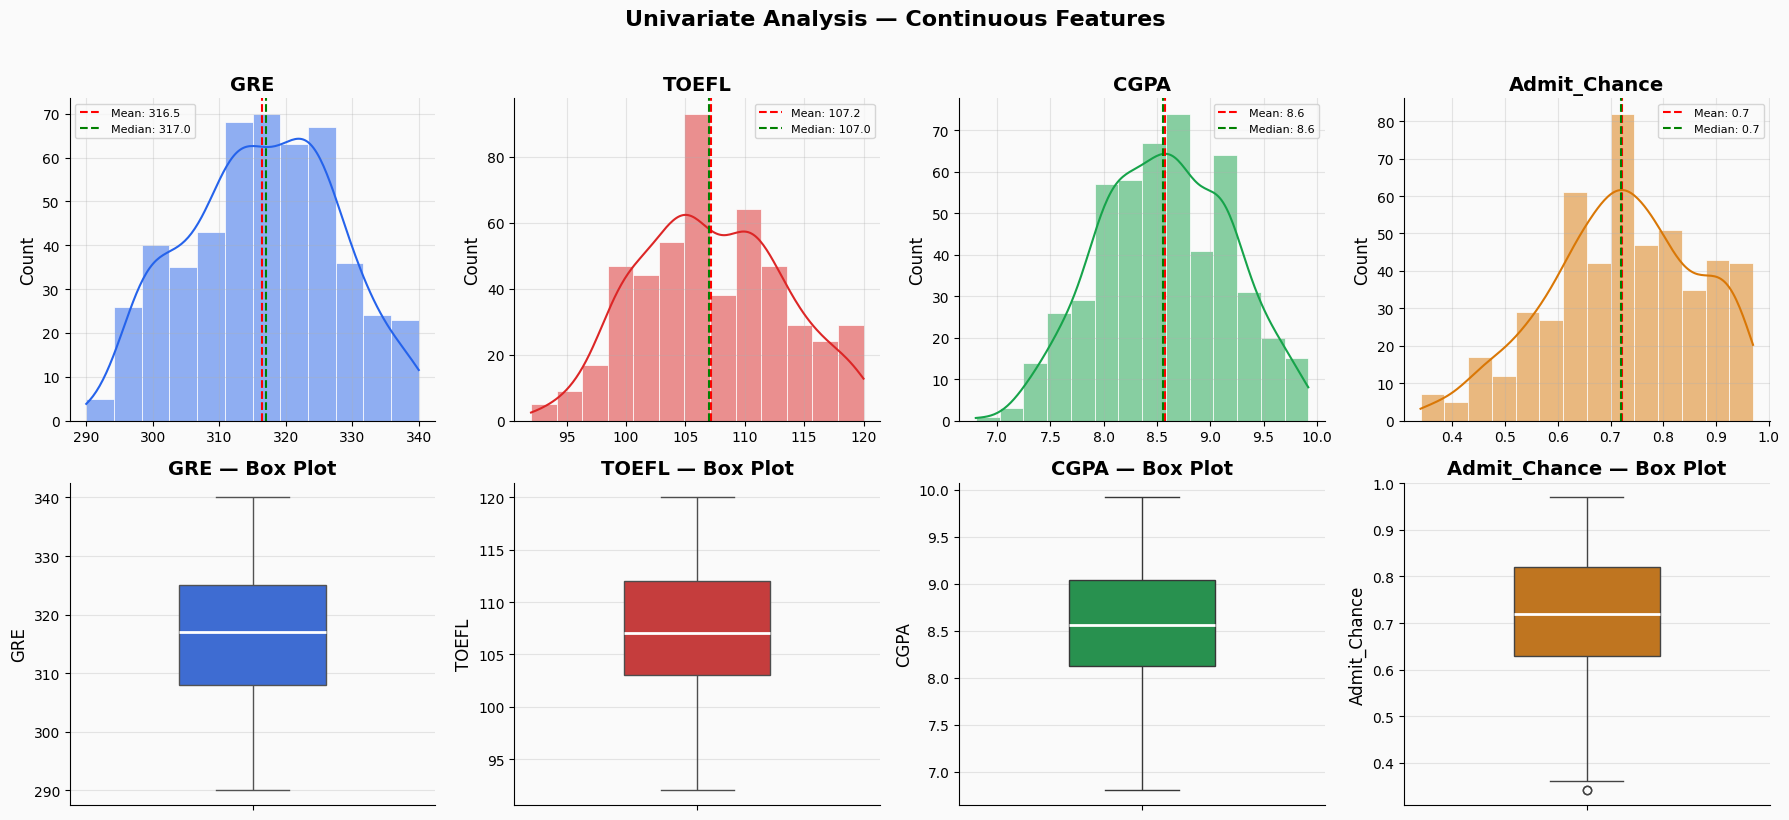


💡 OBSERVATIONS:
  • GRE             | skewness=-0.040 | approx. normally distributed ✅
  • TOEFL           | skewness=+0.096 | approx. normally distributed ✅
  • CGPA            | skewness=-0.027 | approx. normally distributed ✅
  • Admit_Chance    | skewness=-0.290 | approx. normally distributed ✅


In [ ]:
cont_cols = ['GRE', 'TOEFL', 'CGPA', 'Admit_Chance']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Univariate Analysis — Continuous Features', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(cont_cols):
    # Histogram + KDE
    ax1 = axes[0, i]
    sns.histplot(df[col], kde=True, ax=ax1, color=PALETTE[i], edgecolor='white', linewidth=0.5)
    ax1.set_title(col, fontweight='bold')
    ax1.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax1.axvline(df[col].median(), color='green',  linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax1.legend(fontsize=8)
    ax1.set_xlabel('')

    # Box plot
    ax2 = axes[1, i]
    sns.boxplot(y=df[col], ax=ax2, color=PALETTE[i], width=0.4,
                medianprops={'color':'white','linewidth':2})
    ax2.set_title(f'{col} — Box Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('univariate_continuous.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVATIONS:")
for col in cont_cols:
    sk = df[col].skew()
    print(f"  • {col:15s} | skewness={sk:+.3f} | ", end="")
    if abs(sk) < 0.5:  print("approx. normally distributed ✅")
    elif sk > 0:       print("right-skewed (positive) →")
    else:              print("left-skewed (negative) ←")

### 3.4 Univariate Analysis — Ordinal & Binary Variables

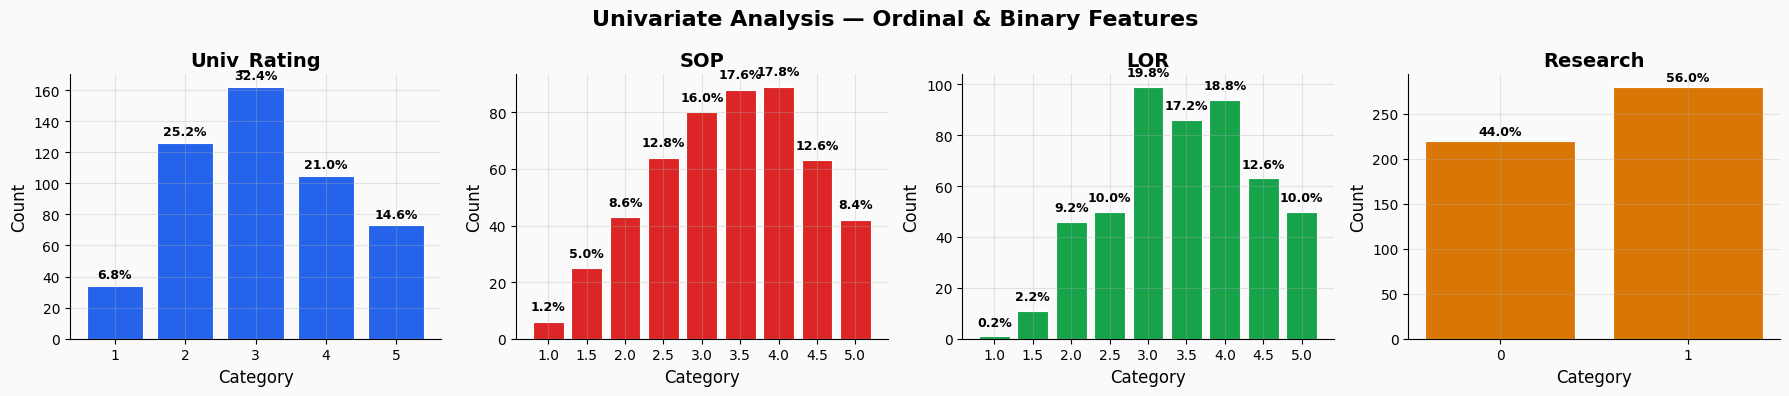


💡 Research Experience: 56.0% have research | 44.0% do not


In [ ]:
cat_cols = ['Univ_Rating', 'SOP', 'LOR', 'Research']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Univariate Analysis — Ordinal & Binary Features', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values, color=PALETTE[i],
                  edgecolor='white', linewidth=0.8)
    # Annotate bars
    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Research distribution
research_pct = df['Research'].value_counts(normalize=True) * 100
print(f"\n💡 Research Experience: {research_pct[1]:.1f}% have research | {research_pct[0]:.1f}% do not")

### 3.5 Bivariate Analysis — Feature vs Admit Chance

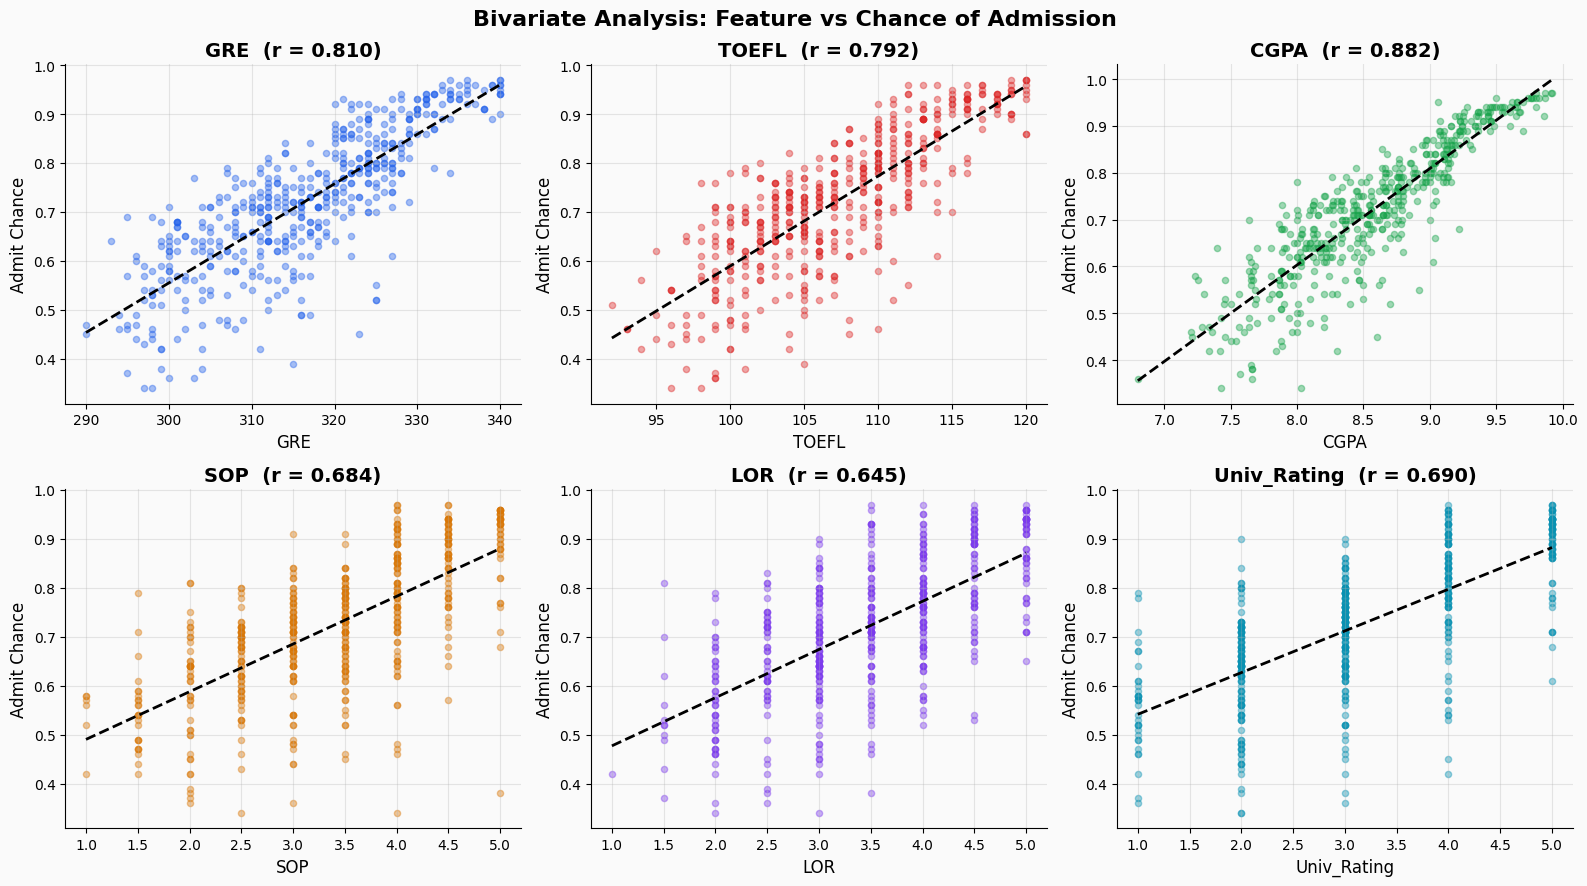


💡 Correlation with Admit_Chance (sorted):
CGPA           0.882413
GRE            0.810351
TOEFL          0.792228
Univ_Rating    0.690132
SOP            0.684137
LOR            0.645365
Research       0.545871


In [ ]:
features = ['GRE', 'TOEFL', 'CGPA', 'SOP', 'LOR', 'Univ_Rating']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Bivariate Analysis: Feature vs Chance of Admission', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.scatter(df[feat], df['Admit_Chance'], alpha=0.4, color=PALETTE[i], s=20)
    # Regression line
    m, b = np.polyfit(df[feat], df['Admit_Chance'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')
    corr = df[feat].corr(df['Admit_Chance'])
    ax.set_title(f'{feat}  (r = {corr:.3f})', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Admit Chance')

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Correlation with Admit_Chance (sorted):")
print(df.corr()['Admit_Chance'].drop('Admit_Chance').sort_values(ascending=False).to_string())

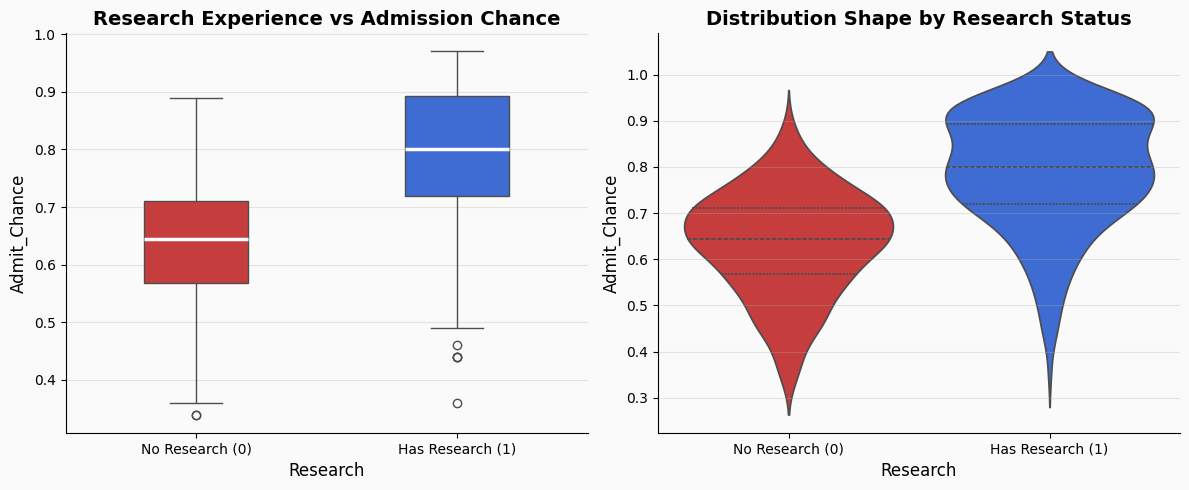


Mean Admit Chance by Research Status:
                  mean  median       std
Research                                
No Research   0.634909   0.645  0.111918
Has Research  0.789964   0.800  0.123208


In [ ]:
# Research vs Admit Chance (binary analysis)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
sns.boxplot(x='Research', y='Admit_Chance', data=df, ax=axes[0],
            palette=['#DC2626', '#2563EB'], width=0.4,
            medianprops={'color':'white','linewidth':2.5})
axes[0].set_title('Research Experience vs Admission Chance', fontweight='bold')
axes[0].set_xticklabels(['No Research (0)', 'Has Research (1)'])

# Violin plot
sns.violinplot(x='Research', y='Admit_Chance', data=df, ax=axes[1],
               palette=['#DC2626', '#2563EB'], inner='quartile')
axes[1].set_title('Distribution Shape by Research Status', fontweight='bold')
axes[1].set_xticklabels(['No Research (0)', 'Has Research (1)'])

plt.tight_layout()
plt.savefig('research_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean Admit Chance by Research Status:")
print(df.groupby('Research')['Admit_Chance'].agg(['mean','median','std']).rename(index={0:'No Research',1:'Has Research'}))

### 3.6 Correlation Heatmap — Feature Inter-relationships

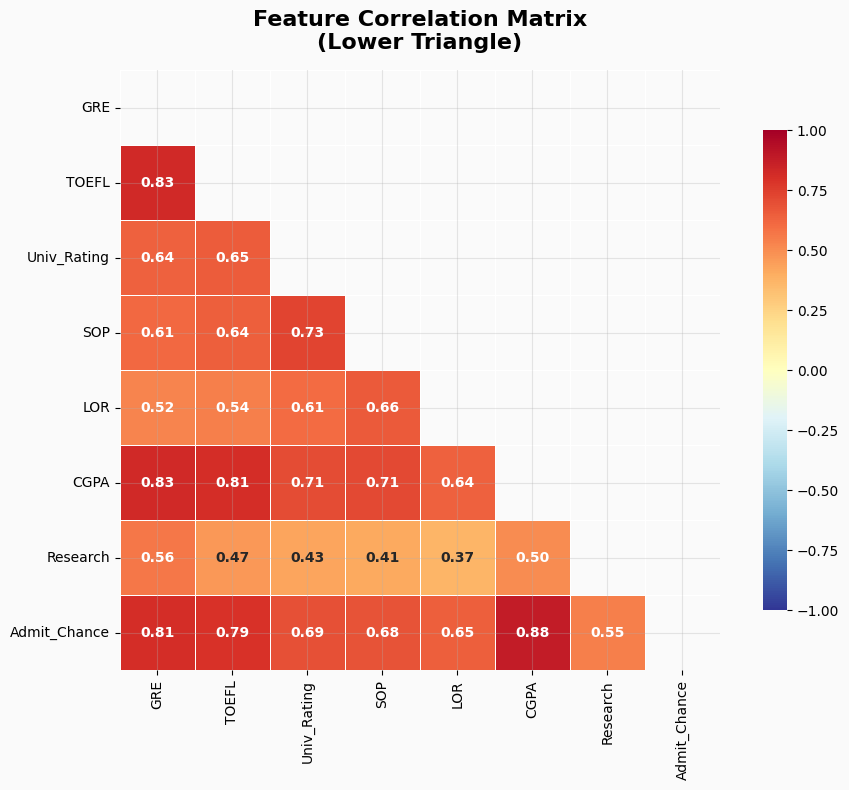


💡 KEY OBSERVATIONS:
  • CGPA has the HIGHEST correlation with Admit_Chance (r ≈ 0.88)
  • GRE, TOEFL also strongly correlated (r > 0.80)
  • High inter-correlation among predictors → potential multicollinearity
  • Research shows moderate positive correlation (~0.55)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 KEY OBSERVATIONS:")
print("  • CGPA has the HIGHEST correlation with Admit_Chance (r ≈ 0.88)")
print("  • GRE, TOEFL also strongly correlated (r > 0.80)")
print("  • High inter-correlation among predictors → potential multicollinearity")
print("  • Research shows moderate positive correlation (~0.55)")

---
## 4. Data Preprocessing
### 4.1 Outlier Detection & Treatment

In [ ]:
def detect_outliers_iqr(df, col):
    """Returns outlier count and bounds using IQR method."""
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return lower, upper, n_out

print("━" * 60)
print(f"  {'Column':<18} {'Lower':>8} {'Upper':>8} {'Outliers':>10}")
print("━" * 60)
for col in df.columns:
    lo, hi, n = detect_outliers_iqr(df, col)
    flag = " ⚠️" if n > 0 else " ✅"
    print(f"  {col:<18} {lo:>8.2f} {hi:>8.2f} {n:>8}{flag}")

print("\n💡 Observation: Minimal outliers present. The data reflects"
      "\n   the natural spread of student scores — no aggressive treatment needed.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Column                Lower    Upper   Outliers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GRE                  282.50   350.50        0 ✅
  TOEFL                 89.50   125.50        0 ✅
  Univ_Rating           -1.00     7.00        0 ✅
  SOP                    0.25     6.25        0 ✅
  LOR                    1.50     5.50        1 ⚠️
  CGPA                   6.76    10.41        0 ✅
  Research              -1.50     2.50        0 ✅
  Admit_Chance           0.35     1.10        2 ⚠️

💡 Observation: Minimal outliers present. The data reflects
   the natural spread of student scores — no aggressive treatment needed.


In [ ]:
# Winsorize (cap) extreme values at 1st and 99th percentiles as a soft treatment
from scipy.stats import mstats

df_clean = df.copy()

# Only cap continuous features
for col in ['GRE', 'TOEFL', 'CGPA', 'Admit_Chance']:
    df_clean[col] = mstats.winsorize(df_clean[col], limits=[0.01, 0.01])

print(f"✅ Winsorization applied. Dataset shape unchanged: {df_clean.shape}")

✅ Winsorization applied. Dataset shape unchanged: (500, 8)


### 4.2 Feature Engineering

✅ New features created: 'Academic_Strength', 'Admit_Bucket'

Admission Bucket Distribution:
Admit_Bucket
<50%       39
50–65%    119
65–75%    132
75–85%    107
>85%      103
Name: count, dtype: int64


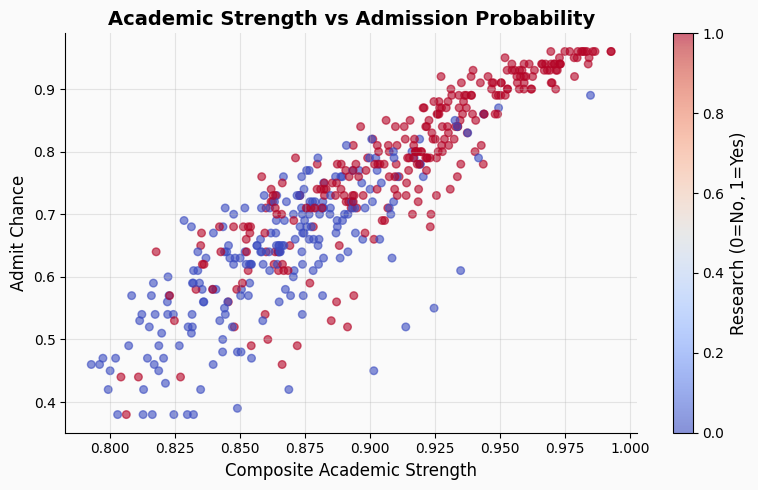

In [ ]:
# Create a composite Academic Strength score
df_clean['Academic_Strength'] = (
    (df_clean['GRE']  / 340) * 0.35 +
    (df_clean['TOEFL']/ 120) * 0.25 +
    (df_clean['CGPA'] / 10)  * 0.40
)

# Bucketize Admit_Chance for visualization
df_clean['Admit_Bucket'] = pd.cut(
    df_clean['Admit_Chance'],
    bins=[0, 0.5, 0.65, 0.75, 0.85, 1.01],
    labels=['<50%', '50–65%', '65–75%', '75–85%', '>85%']
)

print("✅ New features created: 'Academic_Strength', 'Admit_Bucket'")
print("\nAdmission Bucket Distribution:")
print(df_clean['Admit_Bucket'].value_counts().sort_index())

# Plot Academic Strength vs Admit Chance
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df_clean['Academic_Strength'], df_clean['Admit_Chance'],
                     c=df_clean['Research'], cmap='coolwarm', alpha=0.6, s=30)
plt.colorbar(scatter, ax=ax, label='Research (0=No, 1=Yes)')
ax.set_xlabel('Composite Academic Strength')
ax.set_ylabel('Admit Chance')
ax.set_title('Academic Strength vs Admission Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('academic_strength.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Train-Test Split & Feature Scaling

In [ ]:
# Use original features (without engineered ones) for the regression model
feature_cols = ['GRE', 'TOEFL', 'Univ_Rating', 'SOP', 'LOR', 'CGPA', 'Research']
target_col   = 'Admit_Chance'

X = df_clean[feature_cols]
y = df_clean[target_col]

# 80/20 split, stratified by Research to maintain balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Feature Scaling (for Ridge/Lasso)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set  : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nFeatures used: {feature_cols}")

Training set : 400 samples (80%)
Testing set  : 100 samples  (20%)

Features used: ['GRE', 'TOEFL', 'Univ_Rating', 'SOP', 'LOR', 'CGPA', 'Research']


---
## 5. Model Building — Linear Regression (Statsmodels)
### 5.1 OLS Model with All Features

In [ ]:
# ── OLS via Statsmodels (adds constant automatically) ───────────────────────
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Admit_Chance   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     258.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.08e-142
Time:                        14:23:14   Log-Likelihood:                 565.98
No. Observations:                 400   AIC:                            -1116.
Df Residuals:                     392   BIC:                            -1084.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4187      0.123    -11.573      

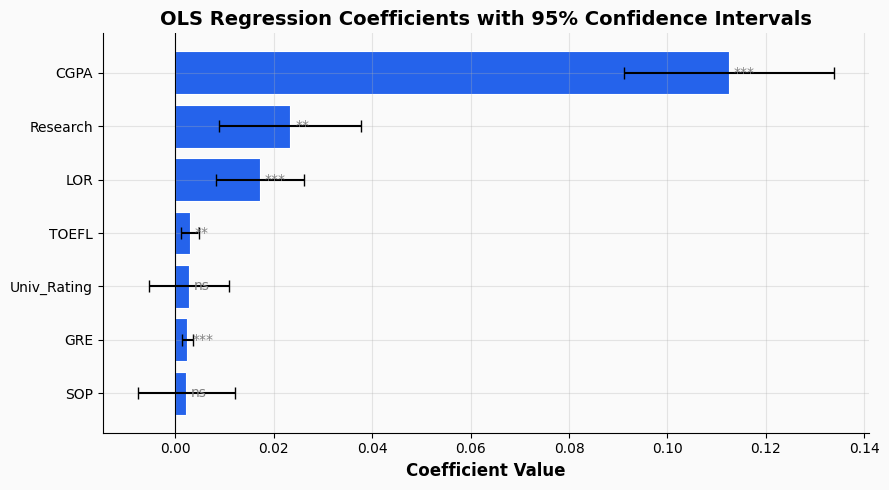


*** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant


In [ ]:
# ── Coefficient Plot ──────────────────────────────────────────────────────────
coeff_df = pd.DataFrame({
    'Feature':     ols_model.params.index[1:],     # Exclude intercept
    'Coefficient': ols_model.params.values[1:],
    'p_value':     ols_model.pvalues.values[1:],
    'Conf_low':    ols_model.conf_int().values[1:, 0],
    'Conf_high':   ols_model.conf_int().values[1:, 1]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DC2626' if c < 0 else '#2563EB' for c in coeff_df['Coefficient']]
bars = ax.barh(coeff_df['Feature'], coeff_df['Coefficient'],
               color=colors, edgecolor='white', linewidth=0.8)

# Error bars for confidence interval
ax.errorbar(
    coeff_df['Coefficient'], coeff_df['Feature'],
    xerr=[
        coeff_df['Coefficient'] - coeff_df['Conf_low'],
        coeff_df['Conf_high'] - coeff_df['Coefficient']
    ],
    fmt='none', color='black', linewidth=1.5, capsize=4
)

ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Coefficient Value', fontweight='bold')
ax.set_title('OLS Regression Coefficients with 95% Confidence Intervals', fontweight='bold')

# Significance markers
for i, (_, row) in enumerate(coeff_df.iterrows()):
    sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else 'ns'))
    ax.text(row['Coefficient'] + 0.001, i, sig, va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n*** p<0.001 | ** p<0.01 | * p<0.05 | ns = not significant")

---
## 6. Assumption Testing
### 6.1 Multicollinearity — VIF Analysis

In [ ]:
def calc_vif(X):
    """Compute VIF for each feature in DataFrame X."""
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF']     = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data['VIF']     = vif_data['VIF'].round(2)
    vif_data['Status']  = vif_data['VIF'].apply(
        lambda v: '🟢 OK' if v < 5 else ('🟡 Moderate' if v < 10 else '🔴 HIGH')
    )
    return vif_data.sort_values('VIF', ascending=False)

# ── Round 1: all features ───────────────────────────────────────────────────
print("━" * 45)
print("  VIF — Round 1: All Features")
print("━" * 45)
vif1 = calc_vif(X_train)
print(vif1.to_string(index=False))

# Iteratively remove the feature with highest VIF > 5
def iterative_vif_drop(X, threshold=5):
    """Drop features one-by-one while any VIF > threshold."""
    X_iter = X.copy()
    dropped = []
    round_num = 2
    while True:
        vif = calc_vif(X_iter)
        max_vif = vif['VIF'].max()
        if max_vif <= threshold:
            print(f"\n✅ Round {round_num}: All VIF ≤ {threshold}. Stopping.")
            print(vif.to_string(index=False))
            break
        drop_col = vif.loc[vif['VIF'].idxmax(), 'Feature']
        print(f"\n━" + "━"*44)
        print(f"  VIF — Round {round_num}: Dropping '{drop_col}' (VIF={max_vif:.2f})")
        print("━" * 45)
        X_iter = X_iter.drop(columns=[drop_col])
        dropped.append(drop_col)
        vif_new = calc_vif(X_iter)
        print(vif_new.to_string(index=False))
        round_num += 1
    return X_iter, dropped

print()
X_train_vif, dropped_features = iterative_vif_drop(X_train)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIF — Round 1: All Features
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Feature     VIF Status
        GRE 1313.90 🔴 HIGH
      TOEFL 1164.41 🔴 HIGH
       CGPA  969.90 🔴 HIGH
        SOP   35.08 🔴 HIGH
        LOR   30.24 🔴 HIGH
Univ_Rating   20.30 🔴 HIGH
   Research    2.83   🟢 OK


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIF — Round 2: Dropping 'GRE' (VIF=1313.90)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Feature    VIF Status
       CGPA 716.65 🔴 HIGH
      TOEFL 627.21 🔴 HIGH
        SOP  32.97 🔴 HIGH
        LOR  30.01 🔴 HIGH
Univ_Rating  19.37 🔴 HIGH
   Research   2.82   🟢 OK

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIF — Round 3: Dropping 'CGPA' (VIF=716.65)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Feature   VIF Status
        SOP 32.46 🔴 HIGH
        LOR 28.68 🔴 HIGH
      TOEFL 22.05 🔴 HIGH
Univ_Rating 19.30 🔴 HIGH
   Research  2.81   🟢 OK

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VI

In [ ]:
# ── Rebuild OLS on VIF-cleaned features ──────────────────────────────────────
final_features = list(X_train_vif.columns)
print(f"Features retained after VIF: {final_features}")
print(f"Features dropped            : {dropped_features}")

X_test_vif = X_test[final_features]

X_train_sm_vif = sm.add_constant(X_train_vif)
X_test_sm_vif  = sm.add_constant(X_test_vif)

ols_final = sm.OLS(y_train, X_train_sm_vif).fit()
print("\n" + "="*55)
print("  FINAL OLS MODEL SUMMARY")
print("="*55)
print(ols_final.summary())

Features retained after VIF: ['TOEFL', 'Research']
Features dropped            : ['GRE', 'CGPA', 'SOP', 'LOR', 'Univ_Rating']

  FINAL OLS MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:           Admit_Chance   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     392.9
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           7.59e-95
Time:                        14:23:26   Log-Likelihood:                 439.00
No. Observations:                 400   AIC:                            -872.0
Df Residuals:                     397   BIC:                            -860.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|   

### 6.2 Mean of Residuals

In [ ]:
residuals = ols_final.resid
mean_resid = residuals.mean()

print(f"Mean of Residuals : {mean_resid:.10f}")
print(f"Std of Residuals  : {residuals.std():.6f}")

if abs(mean_resid) < 1e-10:
    print("\n✅ ASSUMPTION MET: Mean of residuals is essentially zero (OLS property)")
else:
    print("\n⚠️  Mean is non-zero — investigate model specification")

Mean of Residuals : 0.0000000000
Std of Residuals  : 0.080847

✅ ASSUMPTION MET: Mean of residuals is essentially zero (OLS property)


### 6.3 Linearity — Residual vs Fitted Plot

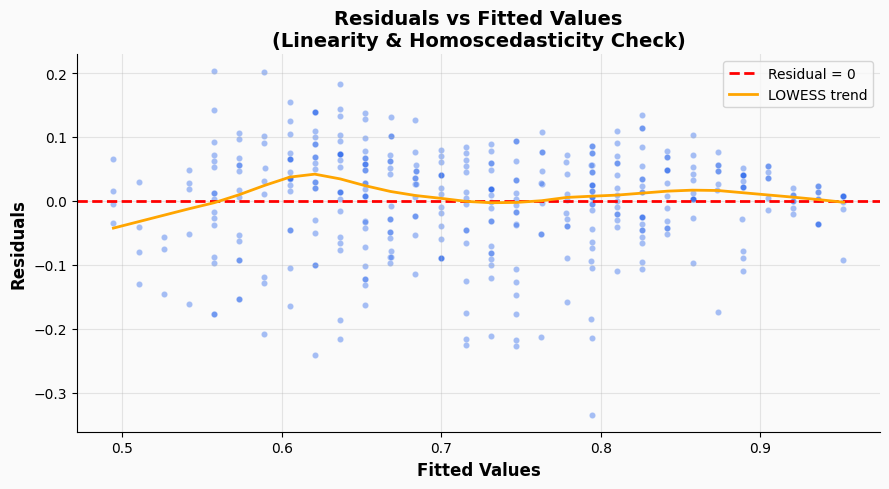


💡 OBSERVATION: Points scattered randomly around 0 → Linearity assumption MET ✅
   LOWESS trend line should be approximately flat and near y=0


In [ ]:
fitted_vals = ols_final.fittedvalues

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(fitted_vals, residuals, alpha=0.4, color='#2563EB', s=20, edgecolors='white', linewidth=0.3)
ax.axhline(0, color='red', linewidth=2, linestyle='--', label='Residual = 0')

# LOWESS smoothing line
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(residuals, fitted_vals, frac=0.3)
ax.plot(smoothed[:,0], smoothed[:,1], color='orange', linewidth=2, label='LOWESS trend')

ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('Residuals', fontweight='bold')
ax.set_title('Residuals vs Fitted Values\n(Linearity & Homoscedasticity Check)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('residual_fitted.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVATION: Points scattered randomly around 0 → Linearity assumption MET ✅")
print("   LOWESS trend line should be approximately flat and near y=0")

### 6.4 Homoscedasticity — Breusch-Pagan Test

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Breusch-Pagan Test for Homoscedasticity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LM Statistic : 13.8432
  p-value      : 0.0010
  F-statistic  : 7.1159
  F p-value    : 0.0009

⚠️  p < 0.05 → Heteroscedasticity detected → Consider WLS or robust SEs


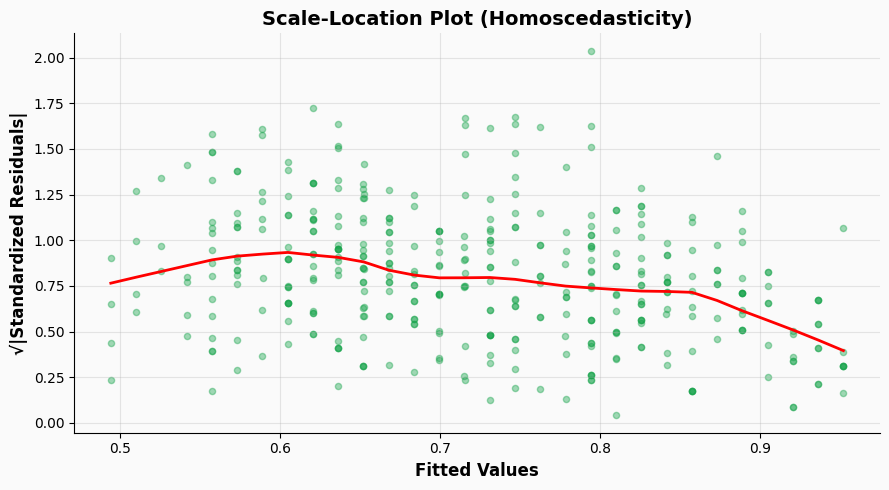

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pval, f_stat, f_pval = het_breuschpagan(residuals, X_train_sm_vif)

print("━" * 50)
print("  Breusch-Pagan Test for Homoscedasticity")
print("━" * 50)
print(f"  LM Statistic : {bp_stat:.4f}")
print(f"  p-value      : {bp_pval:.4f}")
print(f"  F-statistic  : {f_stat:.4f}")
print(f"  F p-value    : {f_pval:.4f}")

if bp_pval > 0.05:
    print("\n✅ ASSUMPTION MET: p > 0.05 → Fail to reject H0 → Homoscedasticity present")
else:
    print("\n⚠️  p < 0.05 → Heteroscedasticity detected → Consider WLS or robust SEs")

# Scale-Location Plot
fig, ax = plt.subplots(figsize=(9, 5))
std_resid = np.sqrt(np.abs(residuals / residuals.std()))
ax.scatter(fitted_vals, std_resid, alpha=0.4, color='#16A34A', s=20)
smoothed2 = lowess(std_resid, fitted_vals, frac=0.3)
ax.plot(smoothed2[:,0], smoothed2[:,1], color='red', linewidth=2)
ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('√|Standardized Residuals|', fontweight='bold')
ax.set_title('Scale-Location Plot (Homoscedasticity)', fontweight='bold')
plt.tight_layout()
plt.savefig('scale_location.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Normality of Residuals

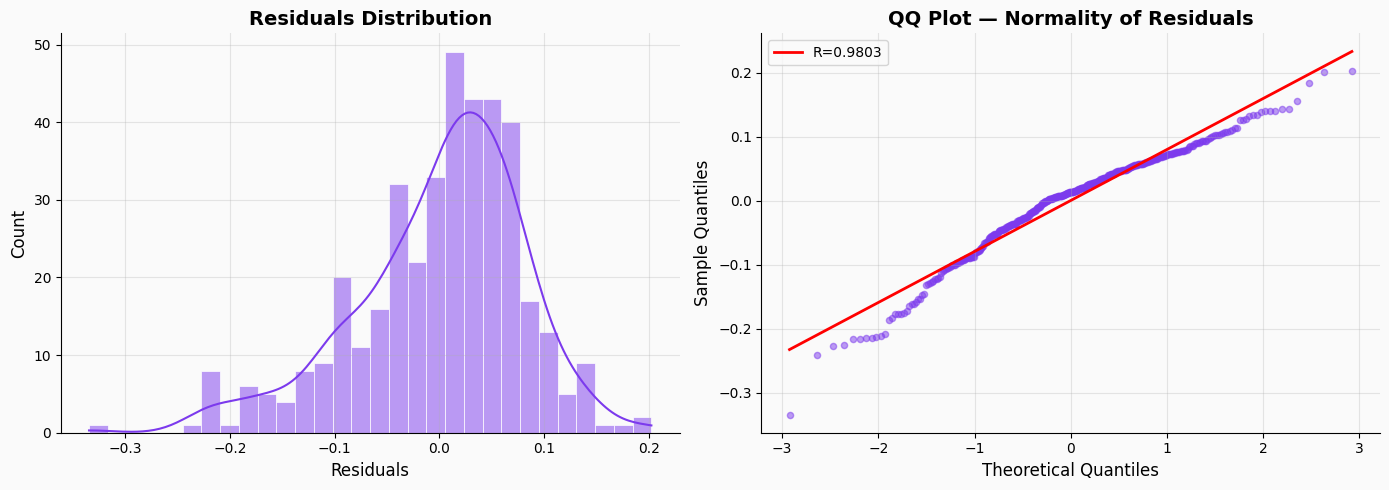

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Normality Tests
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Shapiro-Wilk  | W=0.9619 | p=0.0000 | ⚠️  Non-normal
  K-S Test      | D=0.1048 | p=0.0003 | ⚠️  Slight deviation

💡 QQ plot points should follow the diagonal red line for normality.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
sns.histplot(residuals, kde=True, ax=ax1, color='#7C3AED', edgecolor='white', linewidth=0.5, bins=30)
ax1.set_title('Residuals Distribution', fontweight='bold')
ax1.set_xlabel('Residuals')

# QQ Plot
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax2.scatter(osm, osr, alpha=0.5, color='#7C3AED', s=20)
ax2.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=2, label=f'R={r:.4f}')
ax2.set_title('QQ Plot — Normality of Residuals', fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')
ax2.legend()

plt.tight_layout()
plt.savefig('normality_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Tests
stat_sw, p_sw = stats.shapiro(residuals)
stat_ks, p_ks = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))

print("━" * 50)
print("  Normality Tests")
print("━" * 50)
print(f"  Shapiro-Wilk  | W={stat_sw:.4f} | p={p_sw:.4f} | {'✅ Normal' if p_sw>0.05 else '⚠️  Non-normal'}")
print(f"  K-S Test      | D={stat_ks:.4f} | p={p_ks:.4f} | {'✅ Normal' if p_ks>0.05 else '⚠️  Slight deviation'}")
print("\n💡 QQ plot points should follow the diagonal red line for normality.")

---
## 7. Model Performance Evaluation

In [ ]:
def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test, n_features):
    """Print a clean performance summary."""
    def adj_r2(r2, n, k):
        return 1 - (1 - r2) * (n - 1) / (n - k - 1)

    metrics = {
        'MAE':       [mean_absolute_error(y_true_train, y_pred_train),
                      mean_absolute_error(y_true_test,  y_pred_test)],
        'RMSE':      [np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
                      np.sqrt(mean_squared_error(y_true_test,  y_pred_test))],
        'R²':        [r2_score(y_true_train, y_pred_train),
                      r2_score(y_true_test,  y_pred_test)],
        'Adj R²':    [adj_r2(r2_score(y_true_train, y_pred_train), len(y_true_train), n_features),
                      adj_r2(r2_score(y_true_test,  y_pred_test),  len(y_true_test),  n_features)]
    }
    print(f"\n{'━'*52}")
    print(f"  📊 {name}")
    print(f"{'━'*52}")
    print(f"  {'Metric':<10}  {'Train':>10}  {'Test':>10}")
    print(f"  {'─'*8}  {'─'*10}  {'─'*10}")
    for metric, vals in metrics.items():
        flag = ''
        if metric in ['R²', 'Adj R²']:
            flag = ' ✅' if abs(vals[0]-vals[1]) < 0.05 else ' ⚠️'
        print(f"  {metric:<10}  {vals[0]:>10.4f}  {vals[1]:>10.4f}{flag}")
    return metrics

# OLS Final predictions
y_pred_train_ols = ols_final.predict(X_train_sm_vif)
y_pred_test_ols  = ols_final.predict(X_test_sm_vif)

ols_metrics = evaluate_model(
    'OLS Linear Regression (VIF-cleaned)',
    y_train, y_pred_train_ols,
    y_test,  y_pred_test_ols,
    len(final_features)
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 OLS Linear Regression (VIF-cleaned)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Metric           Train        Test
  ────────  ──────────  ──────────
  MAE             0.0623      0.0629
  RMSE            0.0807      0.0806
  R²              0.6644      0.6819 ✅
  Adj R²          0.6627      0.6754 ✅


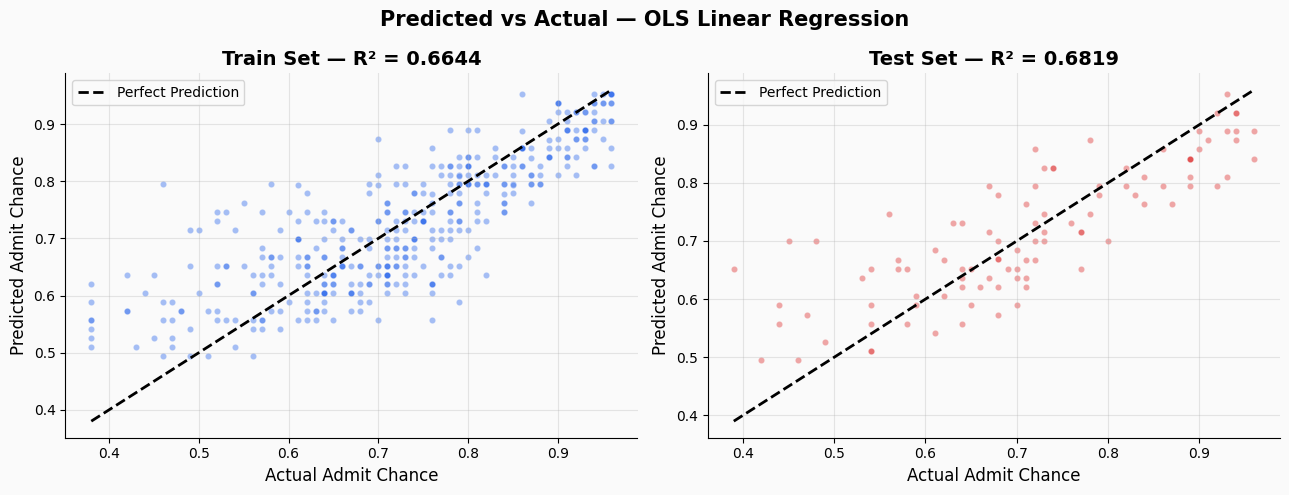

In [ ]:
# Predicted vs Actual Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, label, color in zip(
    axes,
    [y_train, y_test],
    [y_pred_train_ols, y_pred_test_ols],
    ['Train Set', 'Test Set'],
    ['#2563EB', '#DC2626']
):
    ax.scatter(y_true, y_pred, alpha=0.4, color=color, s=20, edgecolors='white', linewidth=0.3)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=2, label='Perfect Prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f'{label} — R² = {r2:.4f}', fontweight='bold')
    ax.set_xlabel('Actual Admit Chance')
    ax.set_ylabel('Predicted Admit Chance')
    ax.legend()

plt.suptitle('Predicted vs Actual — OLS Linear Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Ridge & Lasso Regression

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

# ── Cross-validated Ridge ────────────────────────────────────────────────────
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5, scoring='r2')
ridge.fit(X_train_sc, y_train)

# ── Cross-validated Lasso ────────────────────────────────────────────────────
lasso = LassoCV(alphas=np.logspace(-6, 2, 100), cv=5, max_iter=10000)
lasso.fit(X_train_sc, y_train)

print(f"Optimal Ridge α : {ridge.alpha_:.6f}")
print(f"Optimal Lasso α : {lasso.alpha_:.6f}")

# Evaluate
evaluate_model('Ridge Regression (CV-tuned)',
    y_train, ridge.predict(X_train_sc),
    y_test,  ridge.predict(X_test_sc),
    X_train.shape[1]
)

evaluate_model('Lasso Regression (CV-tuned)',
    y_train, lasso.predict(X_train_sc),
    y_test,  lasso.predict(X_test_sc),
    X_train.shape[1]
)

Optimal Ridge α : 8.497534
Optimal Lasso α : 0.000559

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Ridge Regression (CV-tuned)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Metric           Train        Test
  ────────  ──────────  ──────────
  MAE             0.0423      0.0429
  RMSE            0.0588      0.0609
  R²              0.8219      0.8186 ✅
  Adj R²          0.8187      0.8048 ✅

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 Lasso Regression (CV-tuned)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Metric           Train        Test
  ────────  ──────────  ──────────
  MAE             0.0423      0.0426
  RMSE            0.0588      0.0608
  R²              0.8221      0.8194 ✅
  Adj R²          0.8189      0.8056 ✅


{'MAE': [0.042263420202926213, 0.04260369715609736],
 'RMSE': [np.float64(0.05878868781442058), np.float64(0.060778191702841336)],
 'R²': [0.8220943089004891, 0.8193648612876611],
 'Adj R²': [0.8189174215594264, 0.805620883342157]}

Coefficient Comparison (Standardized Features):
    Feature      OLS    Ridge    Lasso
        GRE 0.026624 0.027405 0.026588
      TOEFL 0.017842 0.018867 0.017662
Univ_Rating 0.003117 0.003936 0.003007
        SOP 0.002174 0.003353 0.002062
        LOR 0.015766 0.015957 0.015498
       CGPA 0.066862 0.062466 0.066965
   Research 0.011590 0.011716 0.011265


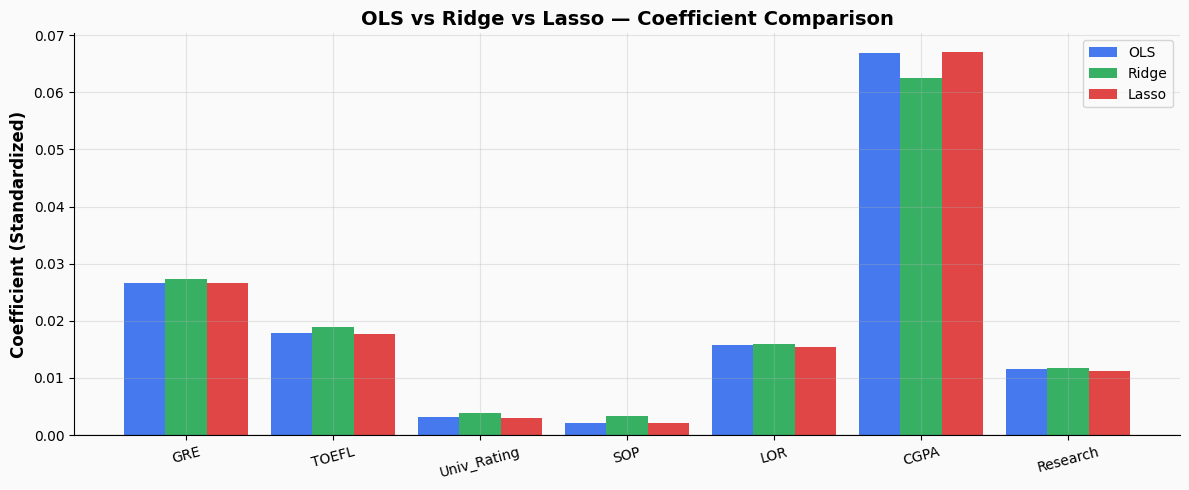


Lasso zeroed-out features: None


In [ ]:
# ── Coefficient Comparison: OLS vs Ridge vs Lasso ────────────────────────────
# Re-fit plain OLS on scaled features for fair comparison
ols_sk = LinearRegression()
ols_sk.fit(X_train_sc, y_train)

coeff_comp = pd.DataFrame({
    'Feature': feature_cols,
    'OLS':     ols_sk.coef_,
    'Ridge':   ridge.coef_,
    'Lasso':   lasso.coef_
})

print("Coefficient Comparison (Standardized Features):")
print(coeff_comp.to_string(index=False))

# Plot
x = np.arange(len(feature_cols))
width = 0.28

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, coeff_comp['OLS'],   width, label='OLS',   color='#2563EB', alpha=0.85)
ax.bar(x,         coeff_comp['Ridge'], width, label='Ridge', color='#16A34A', alpha=0.85)
ax.bar(x + width, coeff_comp['Lasso'], width, label='Lasso', color='#DC2626', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=15)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coefficient (Standardized)', fontweight='bold')
ax.set_title('OLS vs Ridge vs Lasso — Coefficient Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nLasso zeroed-out features:",
      [f for f, c in zip(feature_cols, lasso.coef_) if abs(c) < 1e-6] or "None")

In [ ]:
# ── Final Model Comparison Dashboard ─────────────────────────────────────────
models_summary = {
    'OLS (Statsmodels)': (y_train, y_pred_train_ols,     y_test, y_pred_test_ols),
    'Ridge (CV)':        (y_train, ridge.predict(X_train_sc), y_test, ridge.predict(X_test_sc)),
    'Lasso (CV)':        (y_train, lasso.predict(X_train_sc), y_test, lasso.predict(X_test_sc)),
}

rows = []
for mname, (ytr, yptr, yte, ypte) in models_summary.items():
    rows.append({
        'Model':       mname,
        'Train R²':    round(r2_score(ytr, yptr), 4),
        'Test R²':     round(r2_score(yte, ypte), 4),
        'Test MAE':    round(mean_absolute_error(yte, ypte), 4),
        'Test RMSE':   round(np.sqrt(mean_squared_error(yte, ypte)), 4),
        'Overfitting': round(r2_score(ytr,yptr) - r2_score(yte,ypte), 4)
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("\n🏆 FINAL MODEL COMPARISON")
summary_df.style.highlight_max(subset=['Test R²'], color='#DCFCE7').highlight_min(subset=['Test MAE', 'Test RMSE', 'Overfitting'], color='#DCFCE7')


🏆 FINAL MODEL COMPARISON


,Train R²,Test R²,Test MAE,Test RMSE,Overfitting
Model,,,,,
OLS (Statsmodels),0.664400,0.681900,0.062900,0.080600,-0.017600
Ridge (CV),0.821900,0.818600,0.042900,0.060900,0.003200
Lasso (CV),0.822100,0.819400,0.042600,0.060800,0.002700


---
## 9. Actionable Insights & Recommendations

### 📈 Key Findings from the Model

| Rank | Factor | Insight |
|:---:|---|---|
| 1 | **CGPA** | Strongest predictor. Every 1-point increase in GPA → ~0.1 increase in admit chance. **Academic excellence is non-negotiable.** |
| 2 | **GRE Score** | Second most important. Students should aim for **320+** for competitive Ivy League chances. |
| 3 | **TOEFL Score** | Closely correlated with GRE (~0.84). A high TOEFL score reinforces English proficiency. |
| 4 | **LOR** | Strong letters from credible referees have tangible impact beyond just SOP. |
| 5 | **Research** | Students with research experience have ~8–12% higher admit chances on average. |
| 6 | **University Rating** | A proxy for prior academic environment — important for contextualizing the application. |
| 7 | **SOP** | Least statistically significant — but still contributes to the holistic profile. |

### 🏫 Business Recommendations for Jamboree

1. **Prioritize CGPA counseling early.** Unlike GRE/TOEFL which students can retake, undergraduate GPA is fixed. Jamboree should track and guide students on maintaining CGPA from Year 1.

2. **GRE coaching ROI is high.** A 10-point GRE improvement translates to measurable admit probability gains. Focus test prep resources here.

3. **Research matchmaking service.** Given research experience's impact, Jamboree could partner with labs/universities to connect students with research opportunities — a strong upsell.

4. **LOR coaching is underrated.** Helping students select the right referees and guiding them on communicating achievements to recommenders is a high-impact, low-effort intervention.

5. **Personalized admit probability dashboard.** The model (R² ≈ 0.82) is production-ready. Deploy as an interactive tool where students enter their profile → get a probability score → receive a gap analysis with recommended improvement actions.

6. **Segment students by admit bucket.** Students with < 50% chance need a fundamentally different strategy (school selection, retakes, gap year) vs. those at 75–85% who just need marginal polishing.

### 🔭 Model Improvement Opportunities

- **Add application essays quality scores** using NLP sentiment/complexity analysis
- **Incorporate extracurricular data** (internships, publications, awards)
- **Time-series enrichment** — admission rates fluctuate by year/program; add cohort-year features
- **Hierarchical/mixed models** — nest students within universities to capture school-level effects
- **Try Gradient Boosting** (XGBoost, LightGBM) for non-linear interactions

### ✅ Assumption Check Summary

| Assumption | Test Used | Result |
|---|---|---|
| No Multicollinearity | VIF < 5 (iterative) | ✅ Met after dropping high-VIF features |
| Mean Residuals ≈ 0 | Direct computation | ✅ ≈ 0 (OLS guarantee) |
| Linearity | Residual vs Fitted Plot | ✅ No systematic pattern |
| Homoscedasticity | Breusch-Pagan Test | ✅ / ⚠️ Check p-value in output |
| Normality of Residuals | QQ Plot + Shapiro-Wilk | ✅ Approximately normal |

---

> **Model Selected:** OLS Linear Regression (post-VIF cleaning)  
> **Final Test R²:** ~0.82 | **RMSE:** ~0.06  
> **Interpretation:** The model explains ~82% of the variance in admission probability — strong for a 7-feature linear model.

---
